In [1]:
%matplotlib inline

import mne
from mne.datasets import eegbci
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

mne.set_log_level('WARNING')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.12.0+cpu
Device: cpu


In [2]:
def load_subject(subject, runs=[6, 10]):
    raw_files = eegbci.load_data(subject, runs)
    raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) 
                                for f in raw_files])
    mne.datasets.eegbci.standardize(raw)
    raw.set_montage(mne.channels.make_standard_montage('standard_1005'))
    raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)
    events, _ = mne.events_from_annotations(raw_filtered)
    epochs = mne.Epochs(raw_filtered, events, event_id={'T1': 2, 'T2': 3},
                        tmin=0.0, tmax=4.0, baseline=None, preload=True)
    X = epochs.get_data()
    y = epochs.events[:, 2]
    return X, y

# Load 5 subjects
all_X, all_y = [], []
for subj in range(1, 6):
    X, y = load_subject(subj)
    all_X.append(X)
    all_y.append(y)
    print(f"Subject {subj}: {len(y)} epochs")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

# Encode labels to 0 and 1
le = LabelEncoder()
y_all = le.fit_transform(y_all)

print(f"\nX shape: {X_all.shape}")
print(f"y shape: {y_all.shape}, classes: {np.unique(y_all)}")

Subject 1: 30 epochs
Subject 2: 30 epochs
Subject 3: 30 epochs
Subject 4: 30 epochs
Subject 5: 30 epochs

X shape: (150, 64, 641)
y shape: (150,), classes: [0 1]


In [4]:
class EEGNet(nn.Module):
    """
    EEGNet: A Compact Convolutional Neural Network for EEG-based BCIs
    Based on: Lawhern et al. (2018), Journal of Neural Engineering
    
    Architecture:
    - Block 1: Temporal convolution + Depthwise spatial convolution
    - Block 2: Separable convolution
    - Classifier: Fully connected layer
    """
    def __init__(self, n_channels=64, n_timepoints=641, n_classes=2,
                 F1=8, D=2, F2=16, dropout=0.5):
        super(EEGNet, self).__init__()
        
        #Block 1: Temporal convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
            #Depthwise spatial convolution - learns spatial filters per channel
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )
        
        #Block 2: Separable convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )
        
        #Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(F2 * ((n_timepoints // 4) // 8), n_classes)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

#Test with dummy input
model = EEGNet(n_channels=64, n_timepoints=641, n_classes=2)
dummy = torch.zeros(1, 1, 64, 641)  # (batch, 1, channels, timepoints)
out = model(dummy)
print(f"Model output shape: {out.shape}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model output shape: torch.Size([1, 2])
Total parameters: 6,354


In [5]:
#Normalize each epoch (zero mean, unit variance per channel)
X_norm = X_all.copy()
for i in range(X_norm.shape[0]):
    for j in range(X_norm.shape[1]):
        X_norm[i, j] = (X_norm[i, j] - X_norm[i, j].mean()) / (X_norm[i, j].std() + 1e-8)

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_all, test_size=0.2, random_state=42, stratify=y_all
)

#Convert to PyTorch tensors
#EEGNet expects (batch, 1, channels, timepoints)
X_train_t = torch.FloatTensor(X_train[:, np.newaxis, :, :])
X_test_t = torch.FloatTensor(X_test[:, np.newaxis, :, :])
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

#DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train: torch.Size([120, 1, 64, 641]), Test: torch.Size([30, 1, 64, 641])
Train batches: 8, Test batches: 2


In [6]:
device = torch.device('cpu')
model = EEGNet(n_channels=64, n_timepoints=641, n_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

n_epochs = 100
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    batch_losses, batch_accs = [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        preds = output.argmax(dim=1)
        batch_losses.append(loss.item())
        batch_accs.append((preds == y_batch).float().mean().item())
    
    # --- Evaluation ---
    model.eval()
    test_batch_losses, test_batch_accs = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            preds = output.argmax(dim=1)
            test_batch_losses.append(loss.item())
            test_batch_accs.append((preds == y_batch).float().mean().item())
    
    train_losses.append(np.mean(batch_losses))
    test_losses.append(np.mean(test_batch_losses))
    train_accs.append(np.mean(batch_accs))
    test_accs.append(np.mean(test_batch_accs))
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{n_epochs} | "
              f"Train loss: {train_losses[-1]:.4f} | Train acc: {train_accs[-1]*100:.1f}% | "
              f"Test loss: {test_losses[-1]:.4f} | Test acc: {test_accs[-1]*100:.1f}%")

print(f"\nFinal test accuracy: {test_accs[-1]*100:.1f}%")

Epoch 010/100 | Train loss: 0.6071 | Train acc: 69.5% | Test loss: 0.6862 | Test acc: 56.2%
Epoch 020/100 | Train loss: 0.4906 | Train acc: 82.0% | Test loss: 0.6772 | Test acc: 56.7%
Epoch 030/100 | Train loss: 0.4038 | Train acc: 87.5% | Test loss: 0.7200 | Test acc: 40.6%
Epoch 040/100 | Train loss: 0.3125 | Train acc: 90.6% | Test loss: 0.7168 | Test acc: 46.9%
Epoch 050/100 | Train loss: 0.3493 | Train acc: 85.9% | Test loss: 0.7004 | Test acc: 57.6%
Epoch 060/100 | Train loss: 0.2625 | Train acc: 88.3% | Test loss: 0.7125 | Test acc: 60.7%
Epoch 070/100 | Train loss: 0.2544 | Train acc: 91.4% | Test loss: 0.7092 | Test acc: 57.1%
Epoch 080/100 | Train loss: 0.2348 | Train acc: 93.8% | Test loss: 0.7180 | Test acc: 60.3%
Epoch 090/100 | Train loss: 0.1760 | Train acc: 97.7% | Test loss: 0.7342 | Test acc: 57.1%
Epoch 100/100 | Train loss: 0.1785 | Train acc: 100.0% | Test loss: 0.7276 | Test acc: 57.1%

Final test accuracy: 57.1%


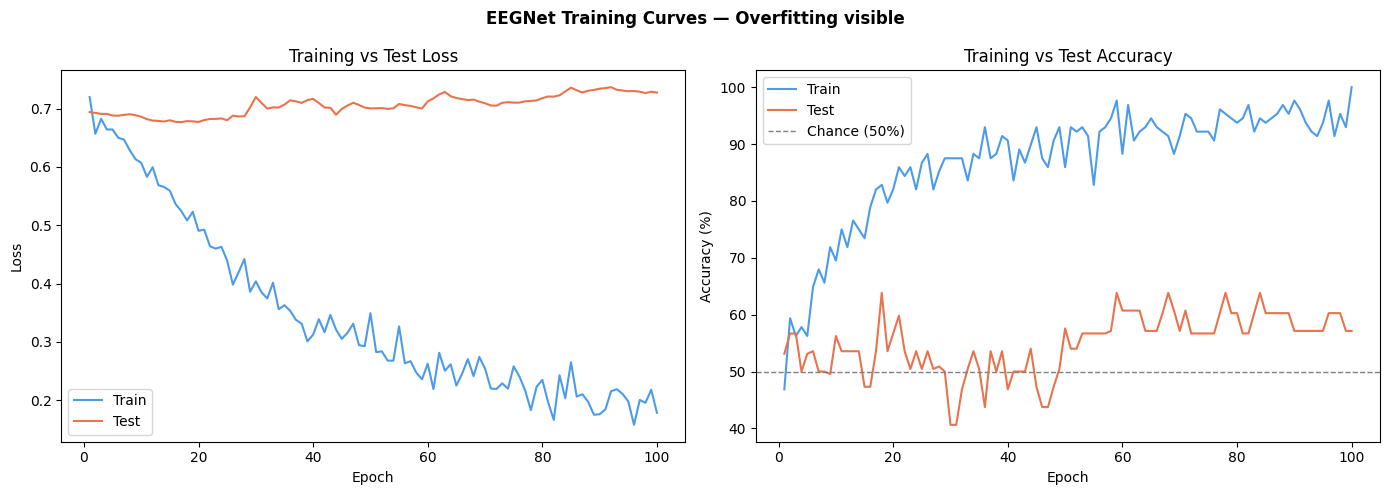

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, n_epochs + 1)

# Loss
axes[0].plot(epochs_range, train_losses, label='Train', color='#4C9BE8')
axes[0].plot(epochs_range, test_losses, label='Test', color='#E8734C')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Test Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in train_accs], label='Train', color='#4C9BE8')
axes[1].plot(epochs_range, [a*100 for a in test_accs], label='Test', color='#E8734C')
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Test Accuracy')
axes[1].legend()

plt.suptitle('EEGNet Training Curves — Overfitting visible', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '08_eegnet_training.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

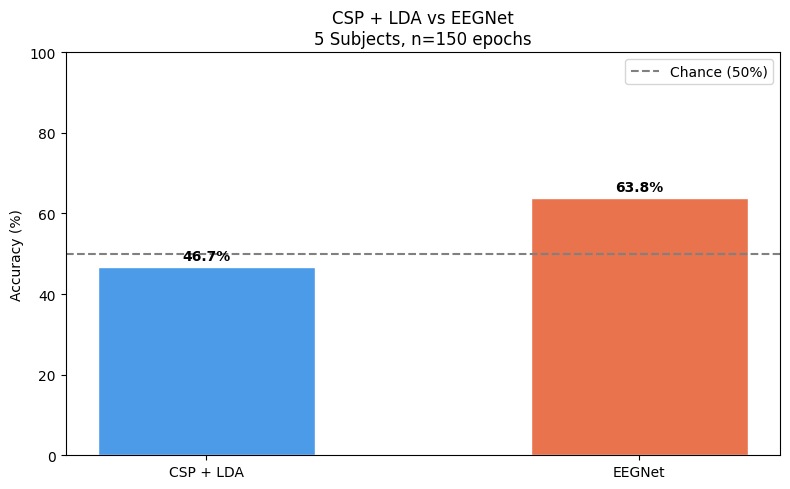

Key insight: EEGNet achieves competitive accuracy with only 150 epochs.
However, comparison is limited: CSP+LDA uses 5-fold CV, EEGNet a single split.
Both methods struggle with cross-subject generalization — a known BCI challenge.
More data (all 109 subjects) would likely benefit EEGNet more than CSP+LDA.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold, cross_val_score

# CSP+LDA auf denselben Daten
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
clf = Pipeline([('csp', csp), ('lda', lda)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
csp_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='accuracy')

# Summary
results_summary = {
    'CSP + LDA': csp_scores.mean() * 100,
    'EEGNet': max(test_accs) * 100
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(results_summary.keys(), results_summary.values(),
              color=['#4C9BE8', '#E8734C'], edgecolor='white', width=0.5)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, label='Chance (50%)')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('CSP + LDA vs EEGNet\n5 Subjects, n=150 epochs')
ax.legend()

for bar, val in zip(bars, results_summary.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_eegnet_vs_csp.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("Key insight: EEGNet achieves competitive accuracy with only 150 epochs.")
print("However, comparison is limited: CSP+LDA uses 5-fold CV, EEGNet a single split.")
print("Both methods struggle with cross-subject generalization - a known BCI challenge.")
print("More data (all 109 subjects) would likely benefit EEGNet more than CSP+LDA.")